In [3]:
import pandas as pd
import os

# Ver qué archivos tenemos
carpeta = '../datos/raw'
for archivo in os.listdir(carpeta):
    print(archivo)

.gitkeep
d-finalidad-funcion-2026.csv
resumen-presupuesto-gastos-ejercicio-vigente-2026.csv
serie_pib_anual.csv


In [4]:
# Cargar los dos archivos
df_finalidad = pd.read_csv('../datos/raw/d-finalidad-funcion-2026.csv')
df_pib = pd.read_csv('../datos/raw/serie_pib_anual.csv')

# Ver las primeras filas de cada uno
print("=== GASTOS POR FINALIDAD ===")
print(df_finalidad.head())
print("\nColumnas:", df_finalidad.columns.tolist())

=== GASTOS POR FINALIDAD ===
   ejercicio_presupuestario  finalidad_id                finalidad_desc  \
0                      2026             1  ADMINISTRACION GUBERNAMENTAL   
1                      2026             1  ADMINISTRACION GUBERNAMENTAL   
2                      2026             1  ADMINISTRACION GUBERNAMENTAL   
3                      2026             1  ADMINISTRACION GUBERNAMENTAL   
4                      2026             1  ADMINISTRACION GUBERNAMENTAL   

   funcion_id                  funcion_desc  \
0           1                   Legislativa   
1           2                      Judicial   
2           3  Dirección Superior Ejecutiva   
3           4         Relaciones Exteriores   
4           5         Relaciones Interiores   

                          ultima_actualizacion_fecha  
0  Última actualización del ejercicio 2026: 06 Ma...  
1  Última actualización del ejercicio 2026: 06 Ma...  
2  Última actualización del ejercicio 2026: 06 Ma...  
3  Última actuali

In [5]:
print("Filas:", len(df_finalidad))
print("\nTodas las columnas:")
print(df_finalidad.columns.tolist())
print("\nPrimeras filas completas:")
df_finalidad.head(10)


Filas: 29

Todas las columnas:
['ejercicio_presupuestario', 'finalidad_id', 'finalidad_desc', 'funcion_id', 'funcion_desc', 'ultima_actualizacion_fecha']

Primeras filas completas:


,ejercicio_presupuestario,finalidad_id,finalidad_desc,funcion_id,funcion_desc,ultima_actualizacion_fecha
0,2026,1,ADMINISTRACION GUBERNAMENTAL,1,Legislativa,Última actualización del ejercicio 2026: 06 Ma...
1,2026,1,ADMINISTRACION GUBERNAMENTAL,2,Judicial,Última actualización del ejercicio 2026: 06 Ma...
2,2026,1,ADMINISTRACION GUBERNAMENTAL,3,Dirección Superior Ejecutiva,Última actualización del ejercicio 2026: 06 Ma...
3,2026,1,ADMINISTRACION GUBERNAMENTAL,4,Relaciones Exteriores,Última actualización del ejercicio 2026: 06 Ma...
4,2026,1,ADMINISTRACION GUBERNAMENTAL,5,Relaciones Interiores,Última actualización del ejercicio 2026: 06 Ma...
5,2026,1,ADMINISTRACION GUBERNAMENTAL,6,Administración Fiscal,Última actualización del ejercicio 2026: 06 Ma...
6,2026,1,ADMINISTRACION GUBERNAMENTAL,7,Control de la Gestión Pública,Última actualización del ejercicio 2026: 06 Ma...
7,2026,1,ADMINISTRACION GUBERNAMENTAL,8,Información y Estadística Básicas,Última actualización del ejercicio 2026: 06 Ma...
8,2026,2,SERVICIOS DE DEFENSA Y SEGURIDAD,1,Defensa,Última actualización del ejercicio 2026: 06 Ma...
9,2026,2,SERVICIOS DE DEFENSA Y SEGURIDAD,2,Seguridad Interior,Última actualización del ejercicio 2026: 06 Ma...


In [6]:
df_resumen = pd.read_csv('../datos/raw/resumen-presupuesto-gastos-ejercicio-vigente-2026.csv')
print(df_resumen.head())
print("\nColumnas:", df_resumen.columns.tolist())

            caracter_desc  jurisdiccion_id           jurisdiccion_desc  \
0  Administración Central                1  Poder Legislativo Nacional   
1  Administración Central                1  Poder Legislativo Nacional   
2  Administración Central                1  Poder Legislativo Nacional   
3  Administración Central                1  Poder Legislativo Nacional   
4  Administración Central                1  Poder Legislativo Nacional   

   subjurisdiccion_id        subjurisdiccion_desc  entidad_id  \
0                   0  Poder Legislativo Nacional           0   
1                   0  Poder Legislativo Nacional           0   
2                   0  Poder Legislativo Nacional           0   
3                   0  Poder Legislativo Nacional           0   
4                   0  Poder Legislativo Nacional           0   

                 entidad_desc  servicio_id  \
0  Poder Legislativo Nacional          312   
1  Poder Legislativo Nacional          312   
2  Poder Legislativo Nacio

In [7]:
print("Filas totales:", len(df_resumen))
print("\nFinalidades:")
print(df_resumen['finalidad_desc'].unique())
print("\nJurisdicciones (primeras 20):")
print(df_resumen['jurisdiccion_desc'].unique()[:20])


Filas totales: 7320

Finalidades:
<StringArray>
[    'ADMINISTRACION GUBERNAMENTAL',               'SERVICIOS SOCIALES',
 'SERVICIOS DE DEFENSA Y SEGURIDAD',             'SERVICIOS ECONOMICOS',
                    'DEUDA PUBLICA']
Length: 5, dtype: str

Jurisdicciones (primeras 20):
<StringArray>
[                                         'Poder Legislativo Nacional',
                                         'Poder Judicial de la Nación',
                                                  'Ministerio Público',
                                            'Presidencia de la Nación',
                                   'Jefatura de Gabinete de Ministros',
                                             'Ministerio del Interior',
 'Ministerio de Relaciones Exteriores, Comercio Internacional y Culto',
                                              'Ministerio de Justicia',
                                    'Ministerio de Seguridad Nacional',
                                               'Minist

In [8]:
# Limpiar columna de montos (tiene comas como separador decimal)
df_resumen['credito_devengado'] = df_resumen['credito_devengado'].astype(str).str.replace(',', '.').astype(float)

# Agrupar por finalidad
gasto_finalidad = df_resumen.groupby('finalidad_desc')['credito_devengado'].sum().sort_values(ascending=False)

print(gasto_finalidad)

finalidad_desc
SERVICIOS SOCIALES                  3.320084e+07
DEUDA PUBLICA                       5.888028e+06
SERVICIOS ECONOMICOS                3.220719e+06
SERVICIOS DE DEFENSA Y SEGURIDAD    2.144020e+06
ADMINISTRACION GUBERNAMENTAL        2.028107e+06
Name: credito_devengado, dtype: float64


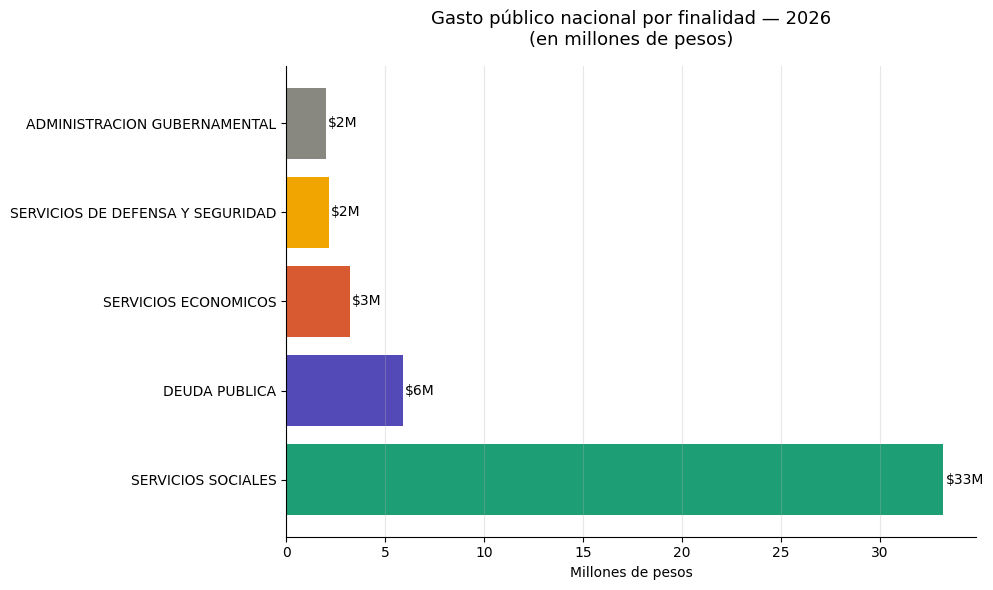

Gráfico guardado en dashboard/


In [9]:
import matplotlib.pyplot as plt

# Convertir a millones para que sea más legible
gasto_millones = gasto_finalidad / 1_000_000

fig, ax = plt.subplots(figsize=(10, 6))

colores = ['#1D9E75', '#534AB7', '#D85A30', '#F0A500', '#888780']

bars = ax.barh(gasto_millones.index, gasto_millones.values, color=colores)

# Etiquetas con valores
for bar, valor in zip(bars, gasto_millones.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'${valor:,.0f}M', va='center', fontsize=10)

ax.set_title('Gasto público nacional por finalidad — 2026\n(en millones de pesos)', 
             fontsize=13, pad=15)
ax.set_xlabel('Millones de pesos')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../dashboard/grafico_finalidad.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico guardado en dashboard/")
